## Agent AI - BACEN SGS Univariate Time-series analysis assistant 

As a PoC, we will first pass a text as an input string and comopare to a previuos defined dictionary BACEN time_series and then get the most suitable string. 

With the most suitable series, we will run time-series pre-process analysis, compute predictions and ake forecast (out-of-sample)

In [ ]:
# fetch_bacen.py
import requests # access HTTP content
from requests.adapters import HTTPAdapter, Retry
import pandas as pd # lib for data manipulation
import numpy as np
from tqdm import tqdm


from tqdm import trange # lib for progress bars
import unicodedata # text normalization

import difflib
from difflib import SequenceMatcher
from bcb import sgs
import re

## sentence_transformers enbedding models
#from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

## Timne-series diagnostics tests
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings("ignore")

## Step 1-  Load data

### Create dictionary of top series from BACEN

In [2]:
BACEN_TOP_SERIES = {
    # 🔹 External sector
    "reservas internacionais total diária": 13621,
    "transações correntes mensal saldo": 22701,

    # 🔹 Interest rates
    "taxa selic diária": 11,
    "taxa selic meta definida pelo copom": 432,
    "taxa selic acumulada no mês": 4390,
    "taxa selic anualizada base 252": 1178,
    "taxa básica financeira tbf": 253,
    "taxa referencial tr": 226,

    # 🔹 Credit and savings
    "Saldo diário de depósitos de poupança - SBPE": 239,
    # "Taxa média de depósitos de poupança (rentabilidade)": 195,
    "taxa média de juros pessoas físicas total": 20716,
    "taxa média de juros pessoas jurídicas total": 20715,
    "taxa média de juros total": 20714,
    "indicador de custo do crédito icc": 25359,

    # 🔹 Inflation indices (CPI)
    "Índice nacional de preços ao consumidor-amplo (IPCA)": 433,
    "Índice nacional de preços ao consumidor-Amplo (IPCA) - Núcleo médias aparadas com suavização": 4466,
    "ipca 15 índice nacional de preços ao consumidor amplo 15": 11428,
    "inpc índice nacional de preços ao consumidor": 188,

    # 🔹 Monetary aggregates
    "base monetária ampliada títulos do tesouro nacional carteira do mercado": 1831,
    "base monetária ampliada títulos do tesouro nacional financiamento líquido": 1832,
    "meios de pagamento ampliados operações compromissadas selic": 1839,
    "meios de pagamento ampliados títulos federais em poder do público selic": 1841,
    "dívida mobiliária participação por indexador posição de custódia": 2238,
    "dívida mobiliária participação por indexador posição em carteira": 4177,

    # 🔹 GDP and Activity
    "pib produto interno bruto trimestral": 4380,
    "pib nominal preço de mercado trimestral": 4382,
    "ibc br índice de atividade econômica do banco central mensal dessazonalizado": 24364,
    "ibc br índice de atividade econômica do banco central mensal original": 24363,

    # 🔹 Inflation expectations (Focus survey)
    "expectativa ipca 12 meses focus média": 4333,

    # 🔹 Exchange rates
    "câmbio comercial venda r$/us$ média": 10813,
    "câmbio efetivo real índice jan 2005 = 100": 11752,
    "câmbio nominal índice jan 2005 = 100": 11753,
}

# TOP_SERIES_CODES = list(BACEN_TOP_SERIES.values())
# TOP_SERIES_CODES

### Create helper functions to make the query text suitable

In [3]:
# # Normalize text prompt for better matching 
def normalize_text(text):
    """
    Normalize text for robust fuzzy matching:
    - Lowercase
    - Remove accents
    - Remove punctuation and symbols
    - Collapse multiple spaces
    """
    if not isinstance(text, str):
        return ""
    # Lowercase and strip
    text = text.lower().strip()

    # Remove accents (normalize to NFD and strip combining marks)
    text = ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )

    # Remove punctuation, symbols, and non-alphanumeric chars (keep spaces)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# get the BACEN CODE from a text prompt - similarity score
def find_bacen_code(prompt, dictionary=BACEN_TOP_SERIES, cutoff=0.3, verbose=True):
    """Find the BACEN code by fuzzy best (similarity) match or partial text match."""

    # Normalize prompt and dictionary keys
    q = normalize_text(prompt)
    normalized_dict = {normalize_text(k): v for k, v in dictionary.items()}

    # Fuzzy best match
    match = difflib.get_close_matches(q, normalized_dict.keys(), n=1, cutoff=cutoff)
    if match:
        best_key = match[0]
        code = normalized_dict[best_key]
        if verbose:
            print(f"Fuzzy match: '{best_key}' → code {code}")
        return code

    # Partial substring match
    partial_matches = {k: v for k, v in normalized_dict.items() if q in k}
    if partial_matches:
        best_key = max(partial_matches, key=len)
        best_code = partial_matches[best_key]
        if verbose:
            print(f"Partial match: '{best_key}' → code {best_code}")
        return best_code

    ## No match
    print("No match found.")
    return None

### Test prompt

In [4]:
print(find_bacen_code("expectativa de IPCA focus média"))
print(find_bacen_code("cambio"))
# find_bacen_code("Selic")
print(find_bacen_code("saldo poupança"))

print(find_bacen_code("selic do Brasil"))

Fuzzy match: 'expectativa ipca 12 meses focus media' → code 4333
4333
Fuzzy match: 'cambio comercial venda r us media' → code 10813
10813
Fuzzy match: 'saldo diario de depositos de poupanca sbpe' → code 239
239
Fuzzy match: 'taxa selic diaria' → code 11
11


## Get data from SGS BACEN

In [5]:
df = sgs.get({'Selic': 4390}, start='2015-01-01', end='2021-01-01')
df.tail()

,Selic
Date,
2020-09-01,0.16
2020-10-01,0.16
2020-11-01,0.15
2020-12-01,0.16
2021-01-01,0.15


#### fetch data from BACEN function 

In [6]:
def fetch_bacen_series(code, start=None, end=None):
    df = sgs.get({str(code): code}, start=start, end=end)
    print(f"Retrieved {len(df)} rows for code {code}.")
    return df   

df = fetch_bacen_series(code = '4390', start='2015-01-01', end='2021-01-01')
df.tail()

Retrieved 73 rows for code 4390.


,4390
Date,
2020-09-01,0.16
2020-10-01,0.16
2020-11-01,0.15
2020-12-01,0.16
2021-01-01,0.15


## Prompt 1

We should make as default values:
* BACEN_TOP_SERIES as the default dictionary;
* todays_date as the max default end date
    * Notice that I can pass the dates anyway I want, but the default value is todays date

In [7]:
### smnall dictionary - just for texting

BACEN_TOP_SERIES = {

    #  Interest rates
    "taxa selic meta definida pelo copom": 432,
    "taxa selic acumulada no mês": 4390,
    "taxa selic anualizada base 252": 1178,
    "taxa básica financeira tbf": 253,
    "taxa referencial tr": 226,
    "taxa selic diária": 11,

    # Exchange rates
    "câmbio comercial venda r$/us$ média": 10813,
    "câmbio efetivo real índice jan 2005 = 100": 11752,
    "câmbio nominal índice jan 2005 = 100": 11753,
}


### Prompt functin to fetch BACEN data

In [8]:
def bacen_agent_load(prompt, dictionary=BACEN_TOP_SERIES, start=None, end=pd.Timestamp.now().normalize()):
    """Understands the prompt, finds the right BACEN code, and loads the data."""
    print(f"\nProcessing prompt: '{prompt}'")

    # -- Noralize text and tokenize
    text = prompt.lower()
    tokens = re.findall(r"[a-zA-ZçÇãõáéíóúâêîôûàèìòù]+", text)
    print(f"Extracted tokens: {tokens}")

    # --- Find best match using fuzzy best match
    found_code = find_bacen_code(prompt, dictionary)
    if found_code:
        print(f"Direct match using full prompt → code {found_code}")
    else:
        for size in range(len(tokens), 0, -1):
            for i in range(len(tokens) - size + 1):
                segment = " ".join(tokens[i:i+size])
                code = find_bacen_code(segment, dictionary)
                if code:
                    found_code = code
                    print(f"Found match with segment '{segment}' → code {code}")
                    break
            if found_code:
                break

    if not found_code:
        print("No BACEN code detected in prompt.")
        return pd.DataFrame(), None

    # --- Fetch the data ---
    try:
        df = sgs.get({str(found_code): found_code}, start=start, end=end)
        df = df.reset_index().rename(columns={"index": "Date", str(found_code): "Value"})
        print(f"Retrieved {len(df)} rows for code {found_code}.")
        return df, found_code
    except Exception as e:
        print(f"Error retrieving data for code {found_code}: {e}")
        return pd.DataFrame(), found_code

In [9]:
### Reset end_date to yesterday
end = pd.Timestamp.now().normalize() - pd.Timedelta(days=1)

df_cambio, code = bacen_agent_load(
    "cambio", 
    start="2020-01-01", 
    end=end)

print(df_cambio.tail())


Processing prompt: 'cambio'
Extracted tokens: ['cambio']
Fuzzy match: 'cambio comercial venda r us media' → code 10813
Direct match using full prompt → code 10813
Retrieved 1469 rows for code 10813.
           Date   Value
1464 2025-10-30  5.3844
1465 2025-10-31  5.3837
1466 2025-11-03  5.3499
1467 2025-11-04  5.3840
1468 2025-11-05  5.3792


### One step further -= Display all possible tokens candidates

1. list all possible matches above a similarity threshold (say, cutoff = 0.3).

2. auto-select the one with the smallest code value (as you suggested).

Make debugging easier — show all candidate matches and their similarity scores.

In [10]:
def bacen_agent_load(prompt, dictionary=BACEN_TOP_SERIES, start=None, end=pd.Timestamp.now().normalize(), cutoff=0.3):
    """Understands the prompt, finds the right BACEN code, lists possible similar matches, and loads the data."""
    print(f"\nProcessing prompt: '{prompt}'")

    # --- Tokenize and normalize ---
    text = normalize_text(prompt)
    tokens = text.split()
    print(f"Extracted tokens: {tokens}")

    # --- Normalize dictionary ---
    normalized_dict = {normalize_text(k): v for k, v in dictionary.items()}

    # --- Filter dictionary to keys that contain any query token ---
    filtered_items = {
        k: v for k, v in normalized_dict.items()
        if any(tok in k for tok in tokens)
    }

    if not filtered_items:
        print("⚠️ No partial matches found based on tokens.")
        return pd.DataFrame(), None

    # --- Compute similarity only within filtered subset ---
    scored = []
    for key, code in filtered_items.items():
        sim = SequenceMatcher(None, text, key).ratio()
        if sim >= cutoff:
            scored.append((key, code, sim))

    if not scored:
        print(f"⚠️ No matches above cutoff {cutoff}.")
        return pd.DataFrame(), None

    scored.sort(key=lambda x: (-x[2], x[1]))

    # --- Display ---
    print(f"\n🔍 Possible matches (similarity ≥ {cutoff}):")
    for key, code, sim in scored:
        print(f"  • {key:<80} → code {code:<6} (similarity={sim:.2f})")

    best_key, best_code, best_sim = scored[0]
    print(f"\nBest match selected: '{best_key}' → code {best_code} (similarity={best_sim:.2f})")

    # --- Fetch data ---
    try:
        df = sgs.get(best_code, start=start, end=end)  # use numeric directly
        df = df.reset_index().rename(columns={"index": "Date", best_code: "Value"})
        print(f"Retrieved {len(df)} rows for code {best_code}.")
        return df, best_code, best_key, best_sim

    except Exception as e:
        print(f"❌ Error retrieving data for code {best_code}: {e}")
        return pd.DataFrame(), best_code

In [11]:
df, code, best_key, best_sim = bacen_agent_load("taxa selic diária praticada no Brasil hoje", start="2020-01-01")


Processing prompt: 'taxa selic diária praticada no Brasil hoje'
Extracted tokens: ['taxa', 'selic', 'diaria', 'praticada', 'no', 'brasil', 'hoje']

🔍 Possible matches (similarity ≥ 0.3):
  • taxa selic acumulada no mes                                                      → code 4390   (similarity=0.61)
  • taxa selic diaria                                                                → code 11     (similarity=0.58)
  • taxa selic anualizada base 252                                                   → code 1178   (similarity=0.56)
  • taxa selic meta definida pelo copom                                              → code 432    (similarity=0.52)
  • taxa referencial tr                                                              → code 226    (similarity=0.36)
  • taxa basica financeira tbf                                                       → code 253    (similarity=0.35)

Best match selected: 'taxa selic acumulada no mes' → code 4390 (similarity=0.61)
Retrieved 71 rows for code 4

### Preliinary Takeaways:

* SequenceMatcher is doing surface-level character overlap, which is weak for semantically similar phrases (e.g. “taxa selic diária praticada no Brasil hoje” vs “taxa selic diaria”).

    * Penalizes word order changes,
    * Ignores meaning,
    * Fails when extra words dilute the match;
    * Need to upgrade the AI Agent to use semantic similarity with embeddings (sentence_transformers) — while keeping it compatible with your current dictionary. 


## Outputs - Time Seriesd Charts

In [12]:
df, code, best_key, best_sim =  bacen_agent_load("cambio comercial", start="2021-01-01")
df


Processing prompt: 'cambio comercial'
Extracted tokens: ['cambio', 'comercial']

🔍 Possible matches (similarity ≥ 0.3):
  • cambio comercial venda r us media                                                → code 10813  (similarity=0.65)
  • cambio nominal indice jan 2005 100                                               → code 11753  (similarity=0.48)
  • cambio efetivo real indice jan 2005 100                                          → code 11752  (similarity=0.40)

Best match selected: 'cambio comercial venda r us media' → code 10813 (similarity=0.65)
Retrieved 1218 rows for code 10813.


,Date,10813
0,2021-01-04,5.1620
1,2021-01-05,5.3263
2,2021-01-06,5.3176
3,2021-01-07,5.3427
4,2021-01-08,5.3677
...,...,...
1213,2025-10-30,5.3844
1214,2025-10-31,5.3837
1215,2025-11-03,5.3499
1216,2025-11-04,5.3840


### Step 1 - Time-series visual charts

In [13]:
def bacen_agent_plot(df, code):
    """
    Fetch, analyze, and plot BACEN series using sentence_transformers-based semantic matching
    """

    if df.empty:
        print("⚠️ No data to plot.")
        return

    if "Value" not in df.columns:
        df = df.rename(columns={df.columns[-1]: "Value"})

    # --- Prepare data ---
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date").sort_index()
    df_returns = df["Value"].pct_change() * 100

    # --- Detect frequency ---
    freq_days = df.index.to_series().diff().median().days
    if freq_days <= 2:
        freq_type = "daily"
        df_resampled = df["Value"].resample("W").mean()
        period = 52
    elif freq_days < 25:
        freq_type = "monthly"
        df_resampled = df["Value"].resample("M").mean()
        period = 12
    else:
        freq_type = "annual"
        df_resampled = df["Value"].copy()
        period = None

    print(f"Detected {freq_type} data → using resampled freq = {df_resampled.index.freqstr or 'W/M'}")

    # --- Plot layout ---
    fig, axes = plt.subplots(2, 2, figsize=(13, 7))
    fig.suptitle(f"BACEN Time  Series {code}", fontsize=12, fontweight="bold")

    axes[0, 0].plot(df.index, df["Value"], color="tab:blue", linewidth=1.5)
    axes[0, 0].set_title("Original Series")

    axes[0, 1].plot(df.index, df_returns, color="tab:orange", linewidth=1)
    axes[0, 1].axhline(0, color="black", linewidth=0.8)
    axes[0, 1].set_title("Returns (Δyₜ / yₜ₋₁)")

    try:
        result = seasonal_decompose(df_resampled.dropna(), model="additive", period=period)
        axes[1, 0].plot(result.trend, color="tab:green")
        axes[1, 0].set_title("Trend")
        axes[1, 1].plot(result.seasonal, color="tab:purple")
        axes[1, 1].set_title("Seasonal (Resampled)")
    except Exception as e:
        print(f"⚠️ Decomposition failed: {e}")

    for ax in axes.flat:
        ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()

Detected daily data → using resampled freq = W-SUN


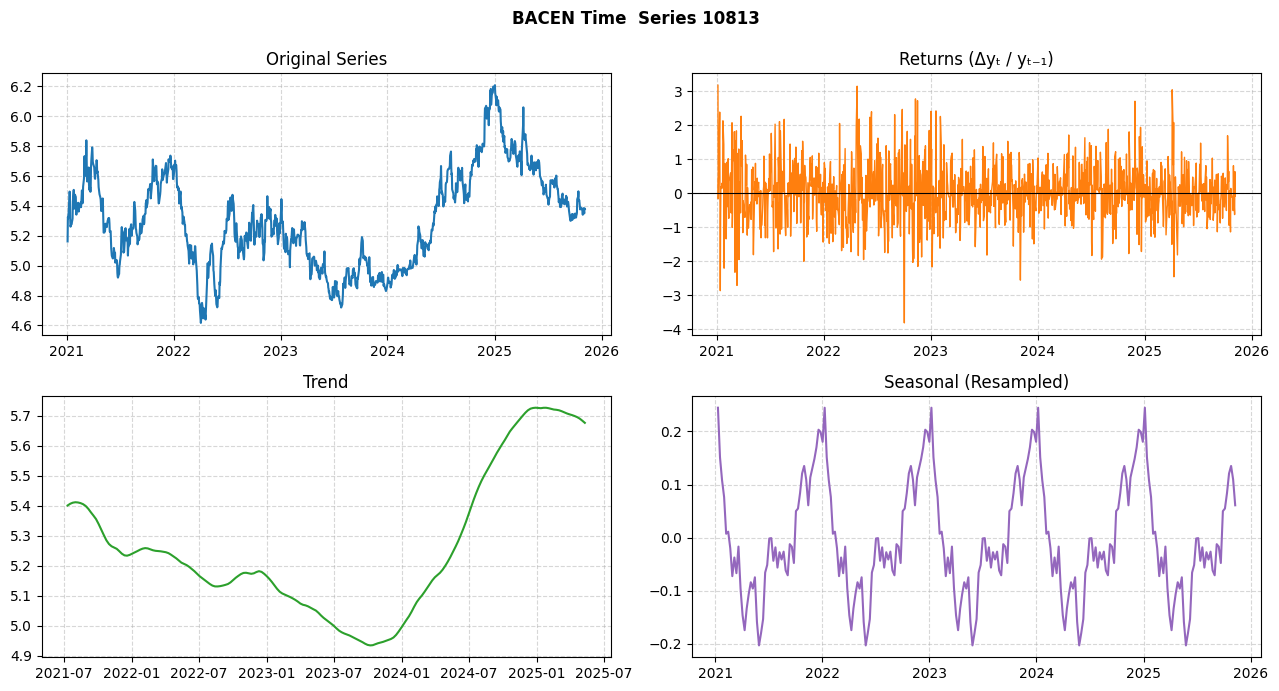

In [14]:
bacen_agent_plot(df, code)

### Step 2 - Pre-test stats for time-series

In [15]:
def time_series_diagnostics(df, lags=12, use_returns=False, title="Time-Series Diagnostics"):
    """
    Compute descriptive and diagnostic statistics for a BACEN time series DataFrame.
    Tests: Descriptive stats, ADF, Ljung-Box (Q and Q²), ARCH LM.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns ['Date', 'Value'].
    lags : int
        Number of lags for autocorrelation tests.
    use_returns : bool
        If True, compute statistics on percentage returns (Δy/yₜ₋₁ * 100) and not on raw_values.
    title : str
        Optional title for printed output.
    """

    if df.empty:
        print("⚠️ No data provided.")
        return

    # --- Ensure proper column names and sorting ---
    if "Value" not in df.columns:
        df = df.rename(columns={df.columns[-1]: "Value"})

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").set_index("Date")

    # --- Use raw levels or returns ---
    if use_returns:
        df["Value"] = df["Value"].pct_change() * 100
        df = df.dropna()
        print("Using percentage returns (Δy/yₜ₋₁ * 100).")

    series = df["Value"]

    # --- Descriptive statistics ---
    n = len(series)
    mean = series.mean()
    std = series.std()
    skew = stats.skew(series)
    kurt = stats.kurtosis(series)
    jb_stat, jb_p = stats.jarque_bera(series)

    # --- Stationarity (ADF test) ---
    try:
        adf_result = adfuller(series, autolag="AIC")
        # adf_stat =  adf_result[0]
        adf_p = adf_result[1]
    except Exception as e:
        print(f"⚠️ ADF test failed: {e}")

    # --- Autocorrelation (Ljung-Box) ---
    lb_results = acorr_ljungbox(df, lags=[12], return_df=True)
    lbq_p = lb_results['lb_pvalue'].values[0]

    # # --- Ljung-Box on squared series (heteroskedasticity) ---
    lb2_results = acorr_ljungbox(df**2, lags=[lags], return_df=False)
    # lbq2_stat = lb2_results['lb_stat'].values[0]
    lbq2_p = lb2_results['lb_pvalue'].values[0]

    # --- ARCH LM test ---
    arch_results = het_arch(series)
    # arch_stat = arch_results[0]
    arch_p = arch_results[1]

    # --- Summary Table ---
    df_diag = pd.DataFrame({
        "Statistic": [
            "Number of observations", 
            "Mean", 
            "Standard deviation",
            "Skewness", 
            "Kurtosis", 
            "Jarque-Bera (p)",
            "ADF (p)",
            "Ljung-Box Q-test (p)", 
            "Ljung-Box Q²-test (p)", 
            "ARCH test (p)"
        ],
        "Value": [
            n,
            round(mean,4),
            round(std,4),
            round(skew,4),
            round(kurt,4),
            round(jb_p,4),
            round(adf_p,4),
            round(lbq_p,4),
            round(lbq2_p,4),
            round(arch_p,4)
        ]
    })

    return df_diag

In [16]:
diag_stats = time_series_diagnostics(df, use_returns=True, lags=12, title=f"BACEN Series {code}")
diag_stats

Using percentage returns (Δy/yₜ₋₁ * 100).


,Statistic,Value
0,Number of observations,1217.0000
1,Mean,0.0068
2,Standard deviation,0.8252
3,Skewness,0.1778
4,Kurtosis,1.2898
5,Jarque-Bera (p),0.0000
6,ADF (p),0.0000
7,Ljung-Box Q-test (p),0.0095
8,Ljung-Box Q²-test (p),0.0000
9,ARCH test (p),0.0000


### Lag definition plots (ACF & PACF)

In [17]:
def plot_acf_pacf(df, lags=24, use_returns=False, title="ACF/PACF Diagnostics"):
    """
    Plot ACF and PACF for BACEN series (levels and/or returns).
    """

    if "Value" not in df.columns:
        df = df.rename(columns={df.columns[-1]: "Value"})

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date").sort_index()

    if use_returns:
        series = df["Value"].pct_change() * 100
        series = series.dropna()
        label = "Percentage Returns (Δy/yₜ₋₁ * 100)"
    else:
        series = df["Value"]
        label = "Raw Series (Levels)"

    # --- Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    fig.suptitle(f"{title} – {label}", fontsize=12, fontweight="bold")

    plot_acf(series, ax=axes[0], lags=lags, alpha=0.05)
    axes[0].set_title("ACF")

    plot_pacf(series, ax=axes[1], lags=lags, alpha=0.05, method="ywm")
    axes[1].set_title("PACF")

    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()

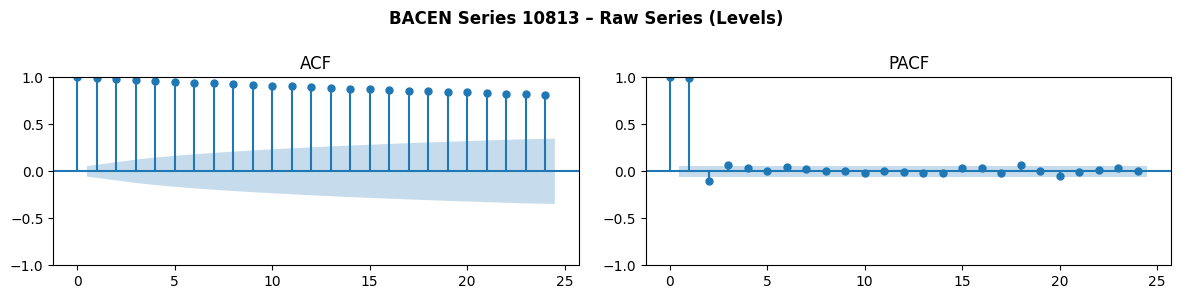

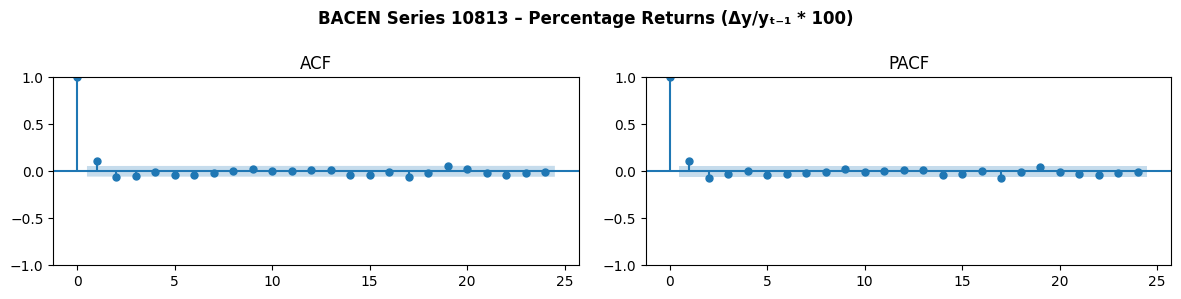

In [18]:
#### plot_acf_pacf(df, lags=24, use_returns=False, title=f"BACEN Series {code}")
plot_acf_pacf(df, lags=24, use_returns=False, title=f"BACEN Series {code}")
plot_acf_pacf(df, lags=24, use_returns=True, title=f"BACEN Series {code}")

## AWS Chronos (Deep-learning) Implementation - Pre-trained models for Univariate Forecasting

AWS deep-learning model for time series forecasting.

A tensor is the core data structure behind PyTorch (and other deep-learning libraries like TensorFlow).

Chronos-2, and related models are deep-learning foundation models for time-series forecasting created by Amazon.
They are built on top of PyTorch (a deep-learning framework) and Transformers (a library that implements modern attention-based neural networks).

 they are PyTorch models, and in a sense they are also GenAI models, because they:

* Use large pre-trained transformer architectures (just like GPT, BERT, or LLaMA);
* Are then fine-tuned for forecasting numerical time-series instead of generating text.


In [19]:
from chronos import ChronosPipeline
from pandas.tseries.frequencies import to_offset
import torch

pipe = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-tiny",
    device_map="cpu"
)

print("✅ Chronos tiny model loaded successfully!")


✅ Chronos tiny model loaded successfully!


In [21]:
import transformers
print(transformers.__version__)

4.43.2


### Implementing AWS Chromos pre-trained model

| Step                                   | What happens                                |
| -------------------------------------  | ------------------------------------------- |
| 1 -  Load Chronos pre-trained model      | Already trained on millions of time series  |
| 2 -  Feed in your full historical sample | Used as conditioning context                |
| 3 -  Generate 20 Monte Carlo futures     | Simulated forecast paths                    |
| 4 -  Summarize to mean (or quantiles)    | Gives a stable point forecast + uncertainty |
| 5 -  Evaluate results                    | Visualize the results                       |

### Step 1 - Load Cromos pre-trained model

In [22]:
# Load the small model (works fine on CPU)
'''initialize CHRONOS pipeline'''
pipeline = ChronosPipeline.from_pretrained("amazon/chronos-t5-tiny")

#pipeline = ChronosPipeline.from_pretrained("amazon/chronos-2-t5-small")

print(pipeline) 

### Step 2 - Load data

In [23]:
# Load data 
context_df = pd.read_csv("https://autogluon.s3.amazonaws.com/datasets/timeseries/m4_hourly/train.csv")
print("Input dataframe shape:", context_df.shape)
display(context_df.head())

Input dataframe shape: (353500, 3)


,item_id,timestamp,target
0,H1,1750-01-01 00:00:00,605.0
1,H1,1750-01-01 01:00:00,586.0
2,H1,1750-01-01 02:00:00,586.0
3,H1,1750-01-01 03:00:00,559.0
4,H1,1750-01-01 04:00:00,511.0


### Create a dictionary of time-series (have sereral time_series per item_id)

In [24]:
# --- Prepare list of dicts (each item_id = one time series) ---
input_data = []
for item_id, group in context_df.groupby("item_id"):
    group = group.sort_values("timestamp")
    input_data.append({
        "item_id": item_id,
        "start": group["timestamp"].iloc[0],
        "target": group["target"].to_numpy()
    })


print(f"✅ Prepared {len(input_data)} time series for forecasting")

✅ Prepared 414 time series for forecasting


### Compute series tensors

In [25]:
# --- Group and convert each series to a Torch tensor ---
series_tensors = []
for _, group in context_df.groupby("item_id"):
    group = group.sort_values("timestamp")
    values = torch.tensor(group["target"].values, dtype=torch.float32)
    series_tensors.append(values)

print(f"Prepared {len(series_tensors)} series as tensors.")


Prepared 414 series as tensors.


### Step 3 - 20 samples to Compute Forecast (24 steps ahead - out-of-sample) 

Chronos (and other probabilistic models like DeepAR, TFT, etc.) generates multiple stochastic samples of the future using random sampling during inference.

By default, Chronos-2’s ChronosPipeline.predict() method uses: 20 random samples

Because of Kernnel problems, we need to re-size the batch_size - it takes about 10 minutes to full run

In [26]:
batch_size = 8  # try 4–8 on CPU, increase if you have >16 GB RAM
forecasts = []

for i in range(0, len(series_tensors), batch_size):
    batch = series_tensors[i:i+batch_size]
    preds = pipeline.predict(batch, prediction_length=24, num_samples=20)
    forecasts.append(preds)


In [27]:
forecast = torch.cat(forecasts)
print("✅ Final forecast shape:", forecast.shape)

✅ Final forecast shape: torch.Size([414, 20, 24])


#### Undersanding the forecast tensor shape: 
* There are 3 elements on forecast.share (i, :, :) 
* 414 -	number of time series $\rightarrow$	one forecast per item_id (we had 414 total)
* 20 -	number of samples $\rightarrow$	Chronos generates 20 Monte Carlo samples for each forecast — i.e., 20 simulated futures per series
* 24 -	prediction length $\rightarrow$	forecast horizon (set prediction_length=24)

So the model produced:

    414 × 20 × 24 = 198,720 predicted values total

### Step 4 - Aggregating the 20 futures

#### Understanding the out-of-sample forecasts (converting to dataframe and numoy)

In [28]:
# Convert forecast tensor → numpy
forecast_np = forecast.detach().cpu().numpy()

## We have 3 elements on forecast.share (i :, :) 

# Automatically flatten to (num_series, prediction_length)
''' One can selelct each simulated eries to or use the average for example'''
# if forecast_np.ndim == 3:
#     forecast_np = forecast_np[:, 0, :]  # using one of the 20 simulated futures per series (the first one)
if forecast_np.ndim == 3:
    forecast_np = forecast_np.mean(axis = 1)  # each [i, :] row is the average prediction across 20 simulated futures for one item.
elif forecast_np.ndim == 2:
    pass  # already fine
else:
    raise ValueError(f"Unexpected forecast shape: {forecast_np.shape}")

print("✅ Forecast array shape:", forecast_np.shape)


✅ Forecast array shape: (414, 24)


#### Converting to a pandas df

In [29]:
forecast_dfs = []

# get unique item_ids in same order
item_ids = list(context_df["item_id"].unique())

for i, (item, group) in enumerate(context_df.groupby("item_id")):
    preds = np.ravel(forecast_np[i])  # ensure 1D
    last_date = pd.to_datetime(group["timestamp"]).max()
    freq = pd.infer_freq(pd.to_datetime(group["timestamp"])) or "H"
    forecast_dates = pd.date_range(last_date, periods=len(preds)+1, freq=freq)[1:]
    
    df_temp = pd.DataFrame({
        "item_id": item,
        "timestamp": forecast_dates,
        "forecast_value": preds
    })
    forecast_dfs.append(df_temp)

forecast_df = pd.concat(forecast_dfs, ignore_index=True)
display(forecast_df.head())



,item_id,timestamp,forecast_value
0,H1,1750-01-30 04:00:00,630.828857
1,H1,1750-01-30 05:00:00,572.684631
2,H1,1750-01-30 06:00:00,531.083435
3,H1,1750-01-30 07:00:00,501.889740
4,H1,1750-01-30 08:00:00,482.670471


In [30]:
context_df_renamed = context_df.rename(columns={"target": "actual_value"})
combined_df = pd.concat(
    [context_df_renamed, forecast_df],
    ignore_index=True
).sort_values(["item_id", "timestamp"])
display(combined_df.tail(10))


,item_id,timestamp,actual_value,forecast_value
69290,H99,1750-01-29 18:00:00,28039.0,NaN
69291,H99,1750-01-29 19:00:00,28432.0,NaN
69292,H99,1750-01-29 20:00:00,28656.0,NaN
69293,H99,1750-01-29 21:00:00,29210.0,NaN
69294,H99,1750-01-29 22:00:00,28981.0,NaN
69295,H99,1750-01-29 23:00:00,27926.0,NaN
69296,H99,1750-01-30 00:00:00,26744.0,NaN
69297,H99,1750-01-30 01:00:00,25829.0,NaN
69298,H99,1750-01-30 02:00:00,25421.0,NaN
69299,H99,1750-01-30 03:00:00,23252.0,NaN


### Step 5 - Visualize the results

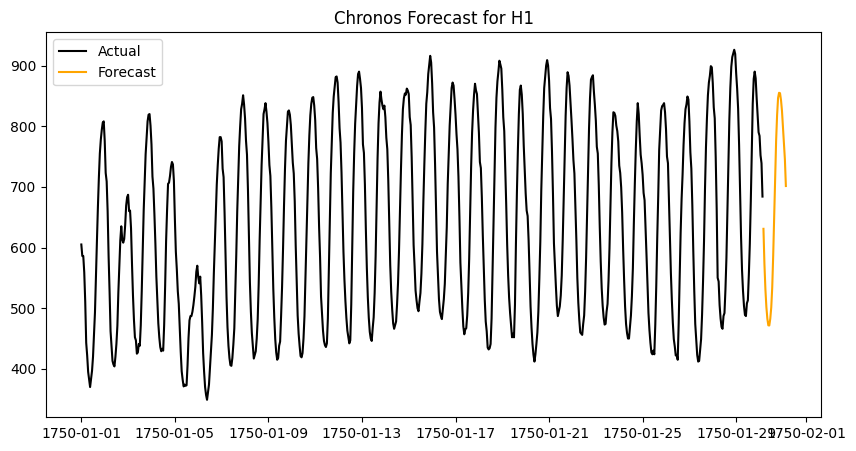

In [31]:
example = "H1"
plot_df = combined_df[combined_df["item_id"] == example]
plt.figure(figsize=(10,5))
plt.plot(plot_df["timestamp"], plot_df["actual_value"], label="Actual", color="black")
plt.plot(plot_df["timestamp"], plot_df["forecast_value"], label="Forecast", color="orange")
plt.title(f"Chronos Forecast for {example}")
plt.legend()
plt.show()


## Apply to Bacen time-series

Chronos expects column names timestamp and target, just like Prophet expects ds and y.

In [32]:
df['item_id'] = code
df = df.rename(columns={
    "Date": "timestamp",
    "10813": "target"
})
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")
df

,timestamp,target,item_id
0,2021-01-04,5.1620,10813
1,2021-01-05,5.3263,10813
2,2021-01-06,5.3176,10813
3,2021-01-07,5.3427,10813
4,2021-01-08,5.3677,10813
...,...,...,...
1213,2025-10-30,5.3844,10813
1214,2025-10-31,5.3837,10813
1215,2025-11-03,5.3499,10813
1216,2025-11-04,5.3840,10813


### Convert to dictionary and get series tensors - way to do it if I have more than one tie-series)

In [33]:
# --- Prepare list of dicts (each item_id = one time series) ---
context_df = df.copy()

input_data = []
for item_id, group in context_df.groupby("item_id"):
    group = group.sort_values("timestamp")
    input_data.append({
        "item_id": item_id,
        "start": group["timestamp"].iloc[0],
        "target": group["target"].to_numpy()
    })


print(f"✅ Prepared {len(input_data)} time series for forecasting")


# --- Group and convert each series to a Torch tensor ---
series_tensors = []
for _, group in context_df.groupby("item_id"):
    group = group.sort_values("timestamp")
    values = torch.tensor(group["target"].values, dtype=torch.float32)
    series_tensors.append(values)

print(f"✅ Prepared {len(series_tensors)} series as tensors.")


✅ Prepared 1 time series for forecasting
✅ Prepared 1 series as tensors.


### Make predictions

In [34]:
batch_size = 8  
forecasts = []

for i in range(0, len(series_tensors), batch_size):
    batch = series_tensors[i:i+batch_size]
    preds = pipeline.predict(batch, prediction_length=24, num_samples=20)
    forecasts.append(preds)

print(preds.shape)

forecast = torch.cat(forecasts)
print("✅ Final forecast shape:", forecast.shape)

torch.Size([1, 20, 24])
✅ Final forecast shape: torch.Size([1, 20, 24])


### Keep average prediction

In [35]:
# Convert forecast tensor → numpy
forecast_np = forecast.detach().cpu().numpy()

## We have 3 elements on forecast.share (i :, :) 

# Automatically flatten to (num_series, prediction_length)
''' One can selelct each simulated eries to or use the average for example'''
# if forecast_np.ndim == 3:
#     forecast_np = forecast_np[:, 0, :]  # using one of the 20 simulated futures per series (the first one)
if forecast_np.ndim == 3:
    forecast_np = forecast_np.mean(axis = 1)  # each [i, :] row is the average prediction across 20 simulated futures for one item.
elif forecast_np.ndim == 2:
    pass  # already fine
else:
    raise ValueError(f"Unexpected forecast shape: {forecast_np.shape}")

print("✅ Forecast array shape:", forecast_np.shape)

✅ Forecast array shape: (1, 24)


In [36]:
forecast_np

array([[5.3815355, 5.393508 , 5.3935075, 5.397498 , 5.3935075, 5.387521 ,
        5.395502 , 5.4014893, 5.393508 , 5.393508 , 5.3974986, 5.403485 ,
        5.4054794, 5.401489 , 5.3994937, 5.391512 , 5.393507 , 5.385526 ,
        5.3895173, 5.3895173, 5.3775444, 5.369563 , 5.369563 , 5.3675675]],
      dtype=float32)

### Convert predictions to pandas

In [37]:
forecast_dfs = []

# get unique item_ids in same order
item_ids = list(context_df["item_id"].unique())

for i, (item, group) in enumerate(context_df.groupby("item_id")):
    preds = np.ravel(forecast_np[i])  # ensure 1D
    last_date = pd.to_datetime(group["timestamp"]).max()
    
     # Try to detect frequency; fallback to daily
    freq = pd.infer_freq(pd.to_datetime(group["timestamp"]))
    if freq is None or freq not in ["D", "W", "M"]:
        freq = "D"
    forecast_dates = pd.date_range(last_date, periods=len(preds)+1, freq=freq)[1:]
    
    df_temp = pd.DataFrame({
        "item_id": item,
        "timestamp": forecast_dates,
        "forecast_value": preds
    })
    forecast_dfs.append(df_temp)

forecast_df = pd.concat(forecast_dfs, ignore_index=True)
display(forecast_df.head())


,item_id,timestamp,forecast_value
0,10813,2025-11-06,5.381536
1,10813,2025-11-07,5.393508
2,10813,2025-11-08,5.393507
3,10813,2025-11-09,5.397498
4,10813,2025-11-10,5.393507


### Display output

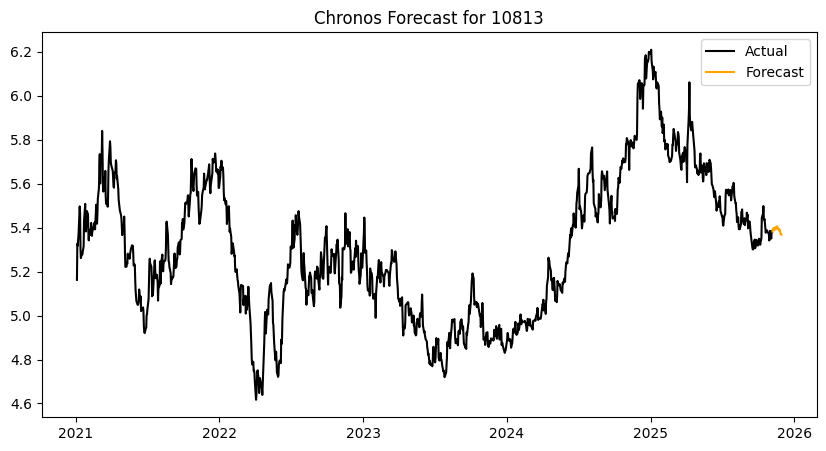

In [38]:
context_df_renamed = context_df.rename(columns={"target": "actual_value"})
combined_df = pd.concat(
    [context_df_renamed, forecast_df],
    ignore_index=True
).sort_values(["item_id", "timestamp"])

example = 10813
plot_df = combined_df[combined_df["item_id"] == example]
plt.figure(figsize=(10,5))
plt.plot(plot_df["timestamp"], plot_df["actual_value"], label="Actual", color="black")
plt.plot(plot_df["timestamp"], plot_df["forecast_value"], label="Forecast", color="orange")
plt.title(f"Chronos Forecast for {example}")
plt.legend()
plt.show()

## Re-feeding different historical slices
Test how the pretrained model performs as we gradually give it more context (longer histories).
* SInce its just one time-series no need to previous convert to a dictionary of n time-series;
* We want to measure robustness to context length.

In [45]:
df

,timestamp,target,item_id
0,2021-01-04,5.1620,10813
1,2021-01-05,5.3263,10813
2,2021-01-06,5.3176,10813
3,2021-01-07,5.3427,10813
4,2021-01-08,5.3677,10813
...,...,...,...
1213,2025-10-30,5.3844,10813
1214,2025-10-31,5.3837,10813
1215,2025-11-03,5.3499,10813
1216,2025-11-04,5.3840,10813


In [ ]:
# Parameters
steps_ahead = 30
initial_train_size = int(0.8 * len(df))
prediction_length = 30  # out-of-sample horizon

## Compute re-feed process results
results = []

for end_idx in tqdm(range(initial_train_size, len(df) - prediction_length, steps_ahead)):
    # Split data
    train_df = df.iloc[:end_idx]
    test_df = df.iloc[end_idx:end_idx + prediction_length]

    # Convert to tensor
    values = torch.tensor(train_df["target"].values, dtype=torch.float32).unsqueeze(0)

    # Forecast using pre-trained Chronos model
    preds = pipeline.predict(values, prediction_length=prediction_length, num_samples=20)
    forecast_np = preds.mean(dim=1).detach().cpu().numpy().flatten()

    # Store results for comparison (in-sample rolling evaluation)
    temp = pd.DataFrame({
        "timestamp": test_df["timestamp"].values,
        "true_value": test_df["target"].values,
        "forecast_value": forecast_np,
        "type": "rolling_eval"
    })
    results.append(temp)

# Combine all rolling forecasts
results_df = pd.concat(results, ignore_index=True)

# Out-of-sample forecast using the full series 
values_out = torch.tensor(df["target"].values, dtype=torch.float32).unsqueeze(0)
preds_out = pipeline.predict(values_out, prediction_length=prediction_length, num_samples=20)
forecast_np_out = preds_out.mean(dim=1).detach().cpu().numpy().flatten()

# Create out-of-sample timestamps
last_date = pd.to_datetime(df["timestamp"]).max()
freq = pd.infer_freq(pd.to_datetime(df["timestamp"])) or "D"
future_dates = pd.date_range(last_date, periods=prediction_length + 1, freq=freq)[1:]

# Combine into DataFrame
out_df = pd.DataFrame({
    "timestamp": future_dates,
    "true_value": np.nan,
    "forecast_value": forecast_np_out,
    "type": "out_of_sample"
})

# Append to the main results
results_df = pd.concat([results_df, out_df], ignore_index=True)

results_df

100%|██████████| 8/8 [00:10<00:00,  1.36s/it]


,timestamp,true_value,forecast_value,type
0,2024-11-18,5.7597,5.786034,rolling_eval
1,2024-11-19,5.7737,5.778481,rolling_eval
2,2024-11-21,5.8167,5.786035,rolling_eval
3,2024-11-22,5.8118,5.780368,rolling_eval
4,2024-11-25,5.7996,5.782257,rolling_eval
...,...,...,...,...
265,2025-12-01,NaN,5.393508,out_of_sample
266,2025-12-02,NaN,5.385526,out_of_sample
267,2025-12-03,NaN,5.389517,out_of_sample
268,2025-12-04,NaN,5.383531,out_of_sample


### Display output

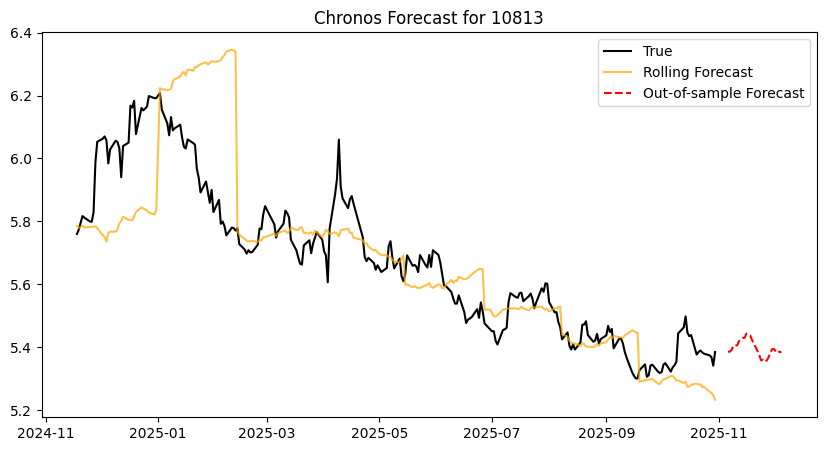

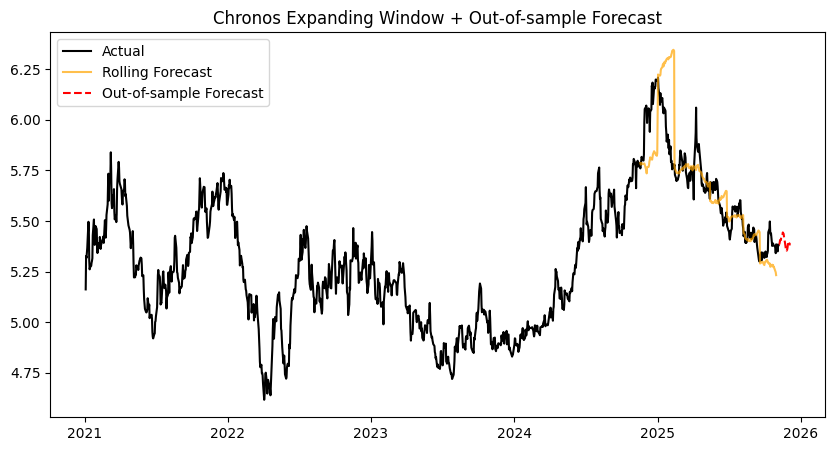

In [42]:
# Testing dataset and out-of-sample forecast 

plt.figure(figsize=(10,5))
plt.plot(results_df["timestamp"], results_df["true_value"], label="True", color="black")
# plt.plot(results_df["timestamp"], results_df["forecast_value"], label="Forecast", color="orange")

plt.plot(results_df[results_df["type"]=="rolling_eval"]["timestamp"],
         results_df[results_df["type"]=="rolling_eval"]["forecast_value"],
         label="Rolling Forecast", color="orange", alpha=0.7)
plt.plot(results_df[results_df["type"]=="out_of_sample"]["timestamp"],
         results_df[results_df["type"]=="out_of_sample"]["forecast_value"],
         label="Out-of-sample Forecast", color="red", linestyle="--")
plt.title(f"Chronos Forecast for {example}")
plt.legend()
plt.show()


# Full data and out-of-sample forecast

plt.figure(figsize=(10,5))
plt.plot(df["timestamp"], df["target"], label="Actual", color="black")
plt.plot(results_df[results_df["type"]=="rolling_eval"]["timestamp"],
         results_df[results_df["type"]=="rolling_eval"]["forecast_value"],
         label="Rolling Forecast", color="orange", alpha=0.7)
plt.plot(results_df[results_df["type"]=="out_of_sample"]["timestamp"],
         results_df[results_df["type"]=="out_of_sample"]["forecast_value"],
         label="Out-of-sample Forecast", color="red", linestyle="--")
plt.legend()
plt.title("Chronos Expanding Window + Out-of-sample Forecast")
plt.show()



### Accuracy metrics

In [ ]:
from sklearn.metrics import mean_absolute_error
eval_df = results_df[results_df["type"] == "rolling_eval"]
# Compute metrics

mae = mean_absolute_error(eval_df["true_value"], eval_df["forecast_value"])

# Avoid division by zero in MAPE
mask = eval_df["true_value"] != 0
mape = np.mean(np.abs((eval_df["true_value"][mask] - eval_df["forecast_value"][mask]) /
                      eval_df["true_value"][mask])) * 100

# Print eval
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 0.1161
MAPE : 2.00%
